# 01 - Baseline CNN Training

Trains the **Baseline CNN** on the **original** (un-augmented) dataset to establish the reference metrics.
The test set is never touched until Section 7.

## 1. Setup & Imports

In [1]:
import os, sys, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

from sklearn.metrics import accuracy_score, f1_score, classification_report
import kagglehub

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# Device
if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

# Add src/ to path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR, '../src'),
          os.path.join(NOTEBOOK_DIR, 'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from transforms import get_transforms
from models import BaselineCNN
from utils import get_splits, get_class_mapping, GLOBAL_SEED
print('Modules imported successfully!')

/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
Modules imported successfully!


## 2. Load Dataset & Reproduce Canonical Splits

Calling `get_splits(df, seed=GLOBAL_SEED)` always produces the same subsets because the input CSV and seed are always identical — no CSV files need to be saved or tracked in Git.

In [2]:
# Get dataset path (instant if already cached)
path = kagglehub.competition_download('aca-tp-2')
train_dir = os.path.join(path, 'train')

df = pd.read_csv(os.path.join(path, 'train.csv'))[['filename', 'label']]

train_df, val_df, test_df = get_splits(df, seed=GLOBAL_SEED)
class_to_idx, idx_to_class, classes = get_class_mapping(df)
NUM_CLASSES = len(classes)

total = len(df)
print(f'Total  : {total}')
print(f'Train  : {len(train_df)}  ({len(train_df)/total*100:.1f}%)')
print(f'Val    : {len(val_df)}   ({len(val_df)/total*100:.1f}%)')
print(f'Test   : {len(test_df)}   ({len(test_df)/total*100:.1f}%)')
print(f'Classes: {NUM_CLASSES}')

Total  : 5199
Train  : 3327  (64.0%)
Val    : 832   (16.0%)
Test   : 1040   (20.0%)
Classes: 75


## 3. DataLoaders

In [3]:
BATCH_SIZE = 32
train_transform, val_transform = get_transforms()

train_dataset = ButterflyDataset(df=train_df, img_dir=train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(df=val_df,   img_dir=train_dir, transform=val_transform)
test_dataset  = ButterflyDataset(df=test_df,  img_dir=train_dir, transform=val_transform)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 104 | Val: 26 | Test: 33


## 4. Model, Loss, Optimizer

In [4]:
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print(model)

BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=75, bias=True)
  (relu): ReLU()
)


## 5. Training Loop

The test set is not used here — only in Section 7.

In [5]:
EPOCHS = 20
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

best_val_f1 = 0.0
best_model_path = '../outputs/models/baseline_cnn_best.pth'
os.makedirs('../outputs/models', exist_ok=True)

for epoch in range(EPOCHS):
    # Training
    model.train()
    trn_loss, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        trn_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    trn_loss /= len(train_dataset)
    trn_acc   = accuracy_score(labels_all, preds_all)

    # Validation
    model.eval()
    val_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss /= len(val_dataset)
    val_acc   = accuracy_score(labels_all, preds_all)
    val_f1    = f1_score(labels_all, preds_all, average='weighted')

    history['train_loss'].append(trn_loss)
    history['train_acc'].append(trn_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {trn_loss:.4f}  Acc: {trn_acc:.4f} '
          f'|| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f'   Best model saved (Val F1: {best_val_f1:.4f})')

print('\nTraining complete!')

Epoch 1/20 [Train]:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 3.9320  Acc: 0.0682 || Val Loss: 3.1802  Acc: 0.1671  F1: 0.1195
   Best model saved (Val F1: 0.1195)


Epoch 2/20 [Train]:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/26 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.2286  Acc: 0.9279 || Val Loss: 2.1634  Acc: 0.5697  F1: 0.5640


Epoch 20/20 [Train]:   0%|          | 0/104 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.1869  Acc: 0.9441 || Val Loss: 2.2412  Acc: 0.5829  F1: 0.5811

Training complete!


## 6. Learning Curves

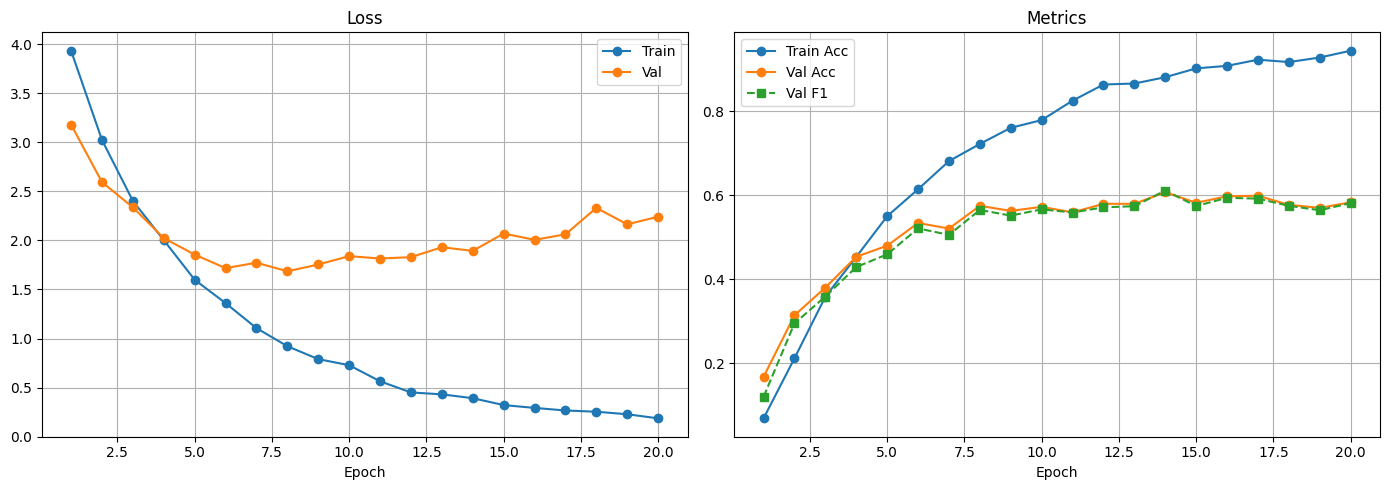

In [6]:
e = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(e, history['train_loss'], label='Train', marker='o')
axes[0].plot(e, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(e, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(e, history['val_acc'],   label='Val Acc',   marker='o')
axes[1].plot(e, history['val_f1'],    label='Val F1',    marker='s', linestyle='--')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

os.makedirs('../outputs', exist_ok=True)
plt.tight_layout()
plt.savefig('../outputs/baseline_learning_curves.png', dpi=150)
plt.show()

## 7. Final Evaluation on the Test Set

Run only once after training. The same test split is used for all model notebooks.

In [7]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

preds_all, labels_all = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Test Set Evaluation'):
        preds_all.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())

test_acc = accuracy_score(labels_all, preds_all)
test_f1  = f1_score(labels_all, preds_all, average='weighted')

print('=' * 50)
print('BASELINE CNN - FINAL TEST SET RESULTS')
print('=' * 50)
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test F1-Score : {test_f1:.4f}  (weighted)')
print('=' * 50)

os.makedirs('../outputs', exist_ok=True)
with open('../outputs/baseline_results.json', 'w') as f:
    json.dump({'model': 'Baseline CNN', 'test_accuracy': test_acc, 'test_f1_weighted': test_f1}, f, indent=2)
print('Saved to ../outputs/baseline_results.json')

Test Set Evaluation:   0%|          | 0/33 [00:00<?, ?it/s]

BASELINE CNN - FINAL TEST SET RESULTS
Test Accuracy : 0.5798
Test F1-Score : 0.5854  (weighted)
Saved to ../outputs/baseline_results.json


## 8. Per-class Analysis

In [8]:
report_df = pd.DataFrame(classification_report(
    labels_all, preds_all,
    target_names=train_dataset.classes,
    output_dict=True
)).T.dropna()

print('10 hardest classes for the Baseline:')
display(report_df.sort_values('f1-score').head(10)[['f1-score', 'support']])

10 hardest classes for the Baseline:


,f1-score,support
PURPLISH COPPER,0.230769,15.0
GREAT EGGFLY,0.250000,12.0
BLUE SPOTTED CROW,0.250000,14.0
SOOTYWING,0.263158,14.0
COMMON BANDED AWL,0.272727,14.0
COPPER TAIL,0.294118,15.0
SLEEPY ORANGE,0.294118,17.0
COMMON WOOD-NYMPH,0.300000,14.0
LARGE MARBLE,0.311111,13.0
STRAITED QUEEN,0.320000,14.0
